In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [9]:
class LinearRegressionGD:
    
    def __init__(self, learning_rate=0.001, n_iters=10000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = 0
        self.b = 0
        self.cost_values = []
        
    def fit(self,X , y):
        
        print("training............")
        
        for i in range(self.n_iters):
            
            # prediction
            y_hat = self.w * X + self.b
            
            # error
            error = y_hat - y
            
            #Gradient
            d_w = np.mean(error * X)
            d_b = np.mean(error)
            
            # update parameters
            self.w = self.w - (self.learning_rate * d_w)
            self.b = self.b - (self.learning_rate * d_b)
            
            # New prediction 
            
            y_hat = self.w * X + self.b
            
            # cost func
            cost = 0.5 * np.mean((y_hat - y)**2)
            self.cost_values.append(cost)
            
        print("Training finished")
            
    
    def predict(self,X):
        
        X = X.flatten()
        return (self.w * X + self.b) 
    
    
    def plot_cost(self):
        
        plt.plot(self.cost_values)
        plt.xlabel("Iterations")
        plt.ylabel("Cost")
        plt.title("Cost Function over Iterations")
        plt.show()
    
    
    
    def plot_regression(self, X_original, X_transformed, y):

        y_pred = self.predict(X_transformed)

        plt.scatter(X_original, y)
        plt.plot(X_original, y_pred)

        plt.xlabel("House Size (m²)")
        plt.ylabel("Price")
        plt.title("Linear Regression")

        plt.show()
            
            
    def get_final_cost(self):

        return self.cost_values[-1]    
        
        
        

In [10]:

X = np.array([50, 60, 70, 80, 90]).reshape(-1, 1)
y = np.array([150, 180, 210, 240, 270])

In [11]:


scaler = MinMaxScaler()

X_transformed = scaler.fit_transform(X)


In [12]:
model = LinearRegressionGD(
    learning_rate=0.0001,
    n_iters=10000
)

model.fit(X_transformed, y)

print("w:", model.w)
print("b:", model.b)

training............
Training finished
w: 55.91214147436013
b: 120.45959433847285


In [21]:
print(X_transformed.flatten())
print(y)

[0.   0.25 0.5  0.75 1.  ]
[150 180 210 240 270]


In [14]:
X_new = np.array([[70]])

X_new_transformed = scaler.transform(X_new)

prediction = model.predict(X_new_transformed)

print(prediction)

[148.41566508]


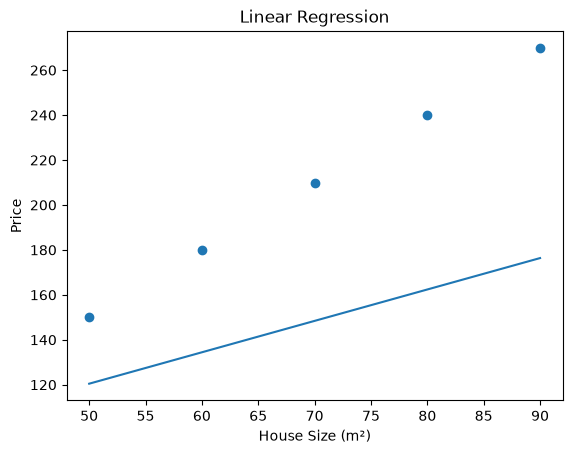

In [15]:
model.plot_regression(
    X_original=X,
    X_transformed=X_transformed,
    y=y
)

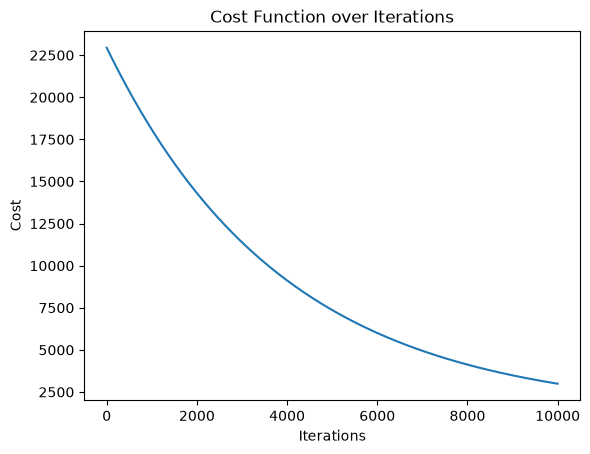

In [16]:
model.plot_cost()

In [17]:
learning_rates = [0.00001, 0.001,0.01, 0.1]

models = {}

for lr in learning_rates:

    model_lr = LinearRegressionGD(
        learning_rate=lr,
        n_iters=10000
    )

    model_lr.fit(X_transformed, y)

    models[lr] = model_lr

training............
Training finished
training............
Training finished
training............
Training finished
training............
Training finished


In [18]:
for lr, model_lr in models.items():

    print(
        f"Learning Rate: {lr} "
        f"| Final Cost: {model_lr.get_final_cost()}"
    )

Learning Rate: 1e-05 | Final Cost: 18084.11647702295
Learning Rate: 0.001 | Final Cost: 971.6095832183793
Learning Rate: 0.01 | Final Cost: 900.0000015833408
Learning Rate: 0.1 | Final Cost: 900.0


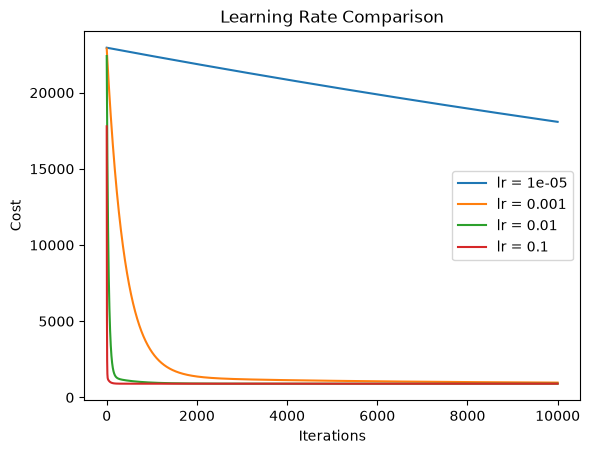

In [19]:
for lr, model_lr in models.items():

    plt.plot(
        model_lr.cost_values,
        label=f"lr = {lr}"
    )

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Learning Rate Comparison")
plt.legend()

plt.show()